import the necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv('../data/transactions_cleaned.csv')
df = pd.read_csv('../data/transactions_raw.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['is_failed'] = (df['status'] == 'Failed').astype(int)

Which channel (UPI,NEFT,Card,RTGS) has the most failures?

In [2]:
channel_failures = df[df['is_failed'] == 1].groupby('payment_channel').size()
print(channel_failures)
print(channel_failures.sum())

payment_channel
Card       416
NEFT       419
RTGS        92
UPI       1147
Wallet     263
dtype: int64
2337


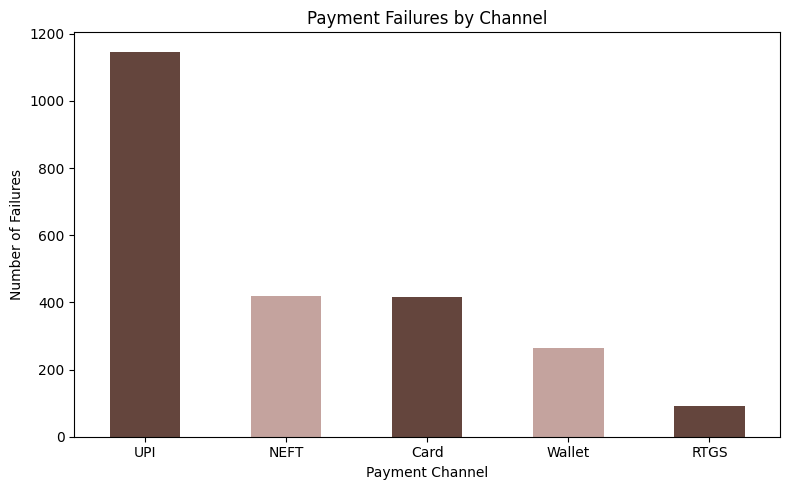

In [3]:
plt.figure(figsize=(8,5))
channel_failures.sort_values(ascending=False).plot(kind='bar',color=['#64453d', '#c4a39e']*len(channel_failures))
plt.title('Payment Failures by Channel')
plt.xlabel('Payment Channel')
plt.ylabel('Number of Failures')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../charts/failure_by_channel.png')
plt.show()

UPI has the highest failure count at 49.08% of all failures despite being one of five channels. This matters for banks because UPI is India's most used payment method that has high failure rates directly impact customer trust.

Among all the failure reasons which one appears the most?

In [4]:
reason_counts = df[df['is_failed'] == 1]['failure_reason'].value_counts()
print(reason_counts)
print(reason_counts.sum())

failure_reason
bank_server_timeout    254
outside_neft_hours     248
account_blocked        247
fraud_blocked          238
invalid_account        234
network_failure        233
insufficient_funds     229
duplicate_txn          227
wrong_pin              215
wrong_ifsc             212
Name: count, dtype: int64
2337


In [6]:
import plotly.express as px

failed_df = df[df['is_failed'] == 1]
reason_counts = failed_df['failure_reason'].value_counts().reset_index()
reason_counts.columns = ['failure_reason', 'count']

fig = px.pie(
    reason_counts,
    names='failure_reason',
    values='count',
    color_discrete_sequence=[
        '#1a0a08','#c4a39e','#2d1410','#d4b8b4','#64453d','#e8d5d2','#8b6f6a','#f0e0de','#b08880',
        '#f8f0ee'
    ]
)

fig.update_traces(
    textinfo='none',
    hovertemplate='<b>%{label}</b><br>Count: %{value}<br>Percentage: %{percent}<extra></extra>'
)

fig.update_layout(title='Distribution of failure causes across payment channels')

fig.show()
fig.write_html('../charts/failure_reason_pie.html')

Bank server timeout is the primary contributor to transaction failures, with the highest recorded count (254). It is closely followed by outside NEFT hours (248) and account blocked cases (247), indicating that both system-related constraints and account restrictions significantly impact transaction success rates.

Which bank has the most failures — SBI, HDFC, ICICI, Axis, or Kotak?

In [8]:
bank_failures = df[df['is_failed'] == 1].groupby('bank_name').size()
print(bank_failures)

bank_name
Axis     494
HDFC     483
ICICI    448
Kotak    451
SBI      461
dtype: int64


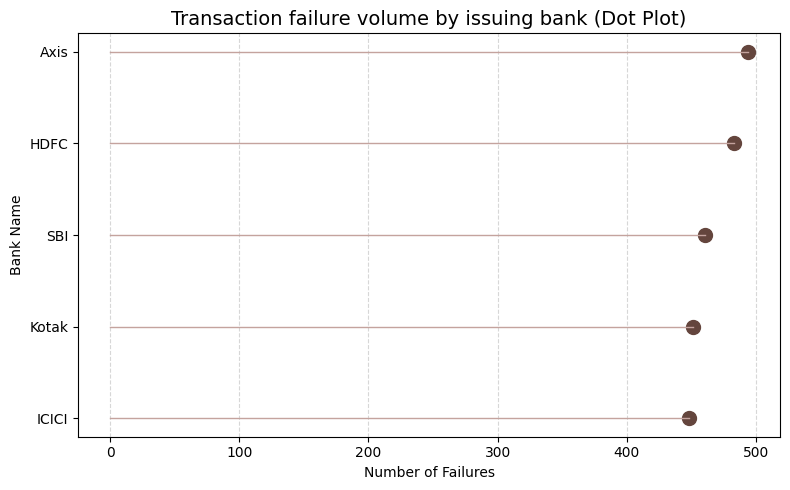

In [9]:
# Sort values
sorted_data = bank_failures.sort_values()

plt.figure(figsize=(8,5))

# Create dot plot
plt.scatter(
    sorted_data.values,        # x-axis (counts)
    sorted_data.index,         # y-axis (bank names)
    color='#64453d', 
    s=100                      # size of dots
)

# Optional: add connecting lines (for better readability)
for i, value in enumerate(sorted_data.values):
    plt.plot([0, value], [i, i], color='#c4a39e', linewidth=1)

plt.title('Transaction failure volume by issuing bank (Dot Plot)', fontsize=14)
plt.xlabel('Number of Failures')
plt.ylabel('Bank Name')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('../charts/failure_by_bank_dot.png')
plt.show()

Axis bank fails the most with 494 cases and followed by HDFC (483 cases).